<a href="https://colab.research.google.com/github/Arnav-techy/Sentimental_analysis_amazon_review/blob/main/Sentimental_analysis_amazon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Sentiment Analysis using BERT  (Dataset: Amazon Review Polarity, 3.6M reviews)

In [1]:
!pip install -q transformers datasets scikit-learn matplotlib tqdm

In [3]:
import random, time
import numpy as np
import torch
import matplotlib.pyplot as plt
from datasets import load_dataset
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, precision_recall_fscore_support)
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from transformers import (AutoModelForSequenceClassification, AutoTokenizer,
                          DataCollatorWithPadding, get_linear_schedule_with_warmup)

MODEL_NAME = "bert-base-uncased"
LABELS = ["negative", "positive"]

TRAIN_SAMPLES = 2000    # was 200,000
VAL_SAMPLES   = 100     # was 5,000
TEST_SAMPLES  = 500     # was 20,000
MAX_LEN       = 128
BATCH_SIZE    = 32
EPOCHS        = 1
LR            = 2e-5
EVAL_EVERY    = 200       # was 1000 (only ~625 steps now, so check more often)
LOG_EVERY     = 50        # was 200
MAX_MINUTES   = 48
SEED          = 42
SAVE_DIR      = "amazon_bert_model"

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if device.type == "cpu":
    print("WARNING: no GPU found. Switch the runtime to T4 GPU.")

Device: cuda


Load dataset


In [4]:
raw = load_dataset("fancyzhx/amazon_polarity")
train_full = raw["train"].shuffle(seed=SEED)

n_train  = TRAIN_SAMPLES or (len(train_full) - VAL_SAMPLES)
train_ds = train_full.select(range(n_train))
val_ds   = train_full.select(range(n_train, n_train + VAL_SAMPLES))
test_ds  = raw["test"].shuffle(seed=SEED)
if TEST_SAMPLES:
    test_ds = test_ds.select(range(TEST_SAMPLES))

print(f"Train {len(train_ds):,} | Val {len(val_ds):,} | Test {len(test_ds):,}")
print("Example:", train_ds[0]["title"], "->", LABELS[train_ds[0]["label"]])

README.md:   0%|          | 0.00/6.81k [00:00<?, ?B/s]

amazon_polarity/train-00000-of-00004.par(…): reconstructing file:   0%|          |  0.00B /  260MB            

amazon_polarity/train-00000-of-00004.par(…): downloading bytes:           |  0.00B            

amazon_polarity/train-00001-of-00004.par(…): reconstructing file:   0%|          |  0.00B /  258MB            

amazon_polarity/train-00001-of-00004.par(…): downloading bytes:           |  0.00B            

...

amazon_polarity/test-00000-of-00001.parq(…): reconstructing file:   0%|          |  0.00B /  117MB            

amazon_polarity/test-00000-of-00001.parq(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/3600000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/400000 [00:00<?, ? examples/s]

Train 2,000 | Val 100 | Test 500
Example: Anyone who likes this better than the Pekinpah is a moron. -> negative


Tokenisez and dataloader

In [5]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    texts = [t.strip() + ". " + c.strip() for t, c in zip(batch["title"], batch["content"])]
    return tokenizer(texts, truncation=True, max_length=MAX_LEN)

def prepare(ds):
    ds = ds.map(tokenize, batched=True, remove_columns=["title", "content"])
    return ds.rename_column("label", "labels")

train_ds, val_ds, test_ds = map(prepare, (train_ds, val_ds, test_ds))

collator = DataCollatorWithPadding(tokenizer)       # pads each batch to its longest item
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collator)
val_loader   = DataLoader(val_ds,   batch_size=128,         shuffle=False, collate_fn=collator)
test_loader  = DataLoader(test_ds,  batch_size=128,         shuffle=False, collate_fn=collator)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Build the model, optimizer and scheduler

In [6]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2,
    id2label=dict(enumerate(LABELS)),
    label2id={l: i for i, l in enumerate(LABELS)},
).to(device)

optimizer   = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS
scheduler   = get_linear_schedule_with_warmup(optimizer, int(0.06 * total_steps), total_steps)

use_amp = device.type == "cuda"                     # fp16 mixed precision = faster
scaler  = torch.amp.GradScaler("cuda", enabled=use_amp)
print(f"Total training steps: {total_steps:,}")

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total training steps: 63


Evaluation Function

In [7]:
@torch.no_grad()
def evaluate(loader, desc="eval"):
    model.eval()
    y_true, y_pred, total = [], [], 0.0
    for batch in tqdm(loader, desc=desc, leave=False):
        batch = {k: v.to(device) for k, v in batch.items()}
        with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=use_amp):
            out = model(**batch)
        total += out.loss.item()
        y_pred += out.logits.argmax(-1).cpu().tolist()
        y_true += batch["labels"].cpu().tolist()
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary")
    return dict(loss=total / len(loader), acc=accuracy_score(y_true, y_pred),
                precision=p, recall=r, f1=f1, y_true=y_true, y_pred=y_pred)

Training loop

In [8]:
hist = {"train_step": [], "train_loss": [], "val_step": [], "val_acc": []}
best_f1, step, running, stop = 0.0, 0, 0.0, False
start = time.time()
bar = tqdm(total=total_steps, desc="training")

for epoch in range(EPOCHS):
    for batch in train_loader:
        model.train()
        batch = {k: v.to(device) for k, v in batch.items()}
        optimizer.zero_grad()
        with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=use_amp):
            loss = model(**batch).loss
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer); scaler.update(); scheduler.step()

        step += 1; running += loss.item(); bar.update(1)
        if step % LOG_EVERY == 0:
            hist["train_step"].append(step)
            hist["train_loss"].append(running / LOG_EVERY)
            bar.set_postfix(loss=f"{running / LOG_EVERY:.4f}")
            running = 0.0

        out_of_time = (time.time() - start) > MAX_MINUTES * 60
        if step % EVAL_EVERY == 0 or step == total_steps or out_of_time:
            val = evaluate(val_loader, "validating")
            hist["val_step"].append(step); hist["val_acc"].append(val["acc"])
            print(f"\nstep {step}/{total_steps} | val acc {val['acc']:.4f} | "
                  f"val F1 {val['f1']:.4f} | {(time.time() - start) / 60:.1f} min")
            if val["f1"] >= best_f1:
                best_f1 = val["f1"]
                model.save_pretrained(SAVE_DIR); tokenizer.save_pretrained(SAVE_DIR)
                print(f"  saved best model -> {SAVE_DIR}")
        if out_of_time:
            print(f"Time limit of {MAX_MINUTES} min reached - stopping.")
            stop = True
            break
    if stop:
        break

bar.close()
print(f"Training finished in {(time.time() - start) / 60:.1f} minutes ({step:,} steps).")

training:   0%|          | 0/63 [00:00<?, ?it/s]

validating:   0%|          | 0/1 [00:00<?, ?it/s]


step 63/63 | val acc 0.9200 | val F1 0.9273 | 0.2 min


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  saved best model -> amazon_bert_model
Training finished in 0.3 minutes (63 steps).


In [10]:
needed = ["device", "train_ds", "val_ds", "test_ds", "train_loader", "val_loader",
          "tokenizer", "model", "optimizer", "scheduler", "scaler", "use_amp",
          "total_steps", "evaluate"]
missing = [n for n in needed if n not in globals()]
print("Missing:", missing if missing else "none - safe to run Block 7")

Missing: none - safe to run Block 7


Final test results and figures

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

testing:   0%|          | 0/4 [00:00<?, ?it/s]

===== TEST RESULTS (500 unseen reviews) =====
Accuracy 0.9220 | Precision 0.9228 | Recall 0.9190 | F1 0.9209

              precision    recall  f1-score   support

    negative     0.9213    0.9249    0.9231       253
    positive     0.9228    0.9190    0.9209       247

    accuracy                         0.9220       500
   macro avg     0.9220    0.9220    0.9220       500
weighted avg     0.9220    0.9220    0.9220       500



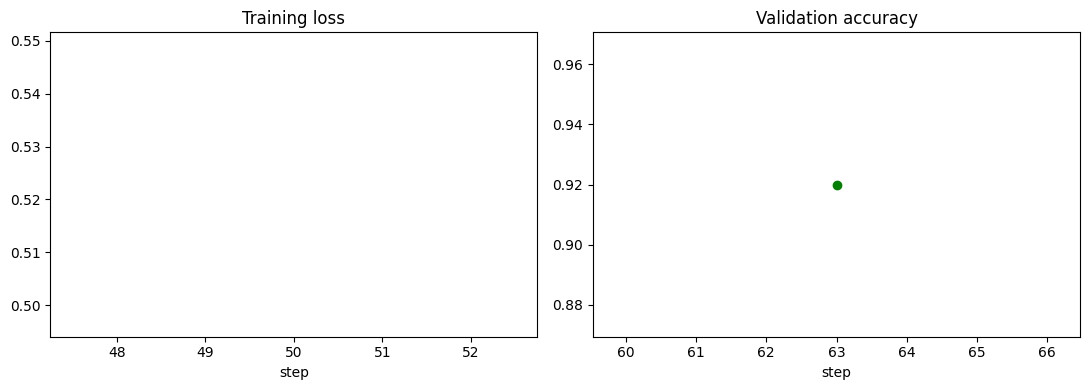

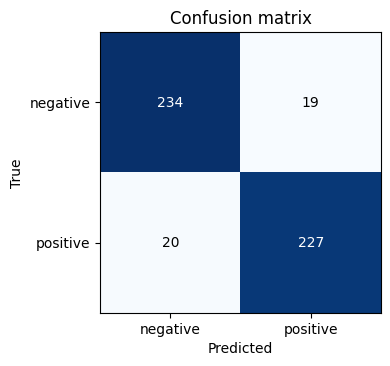

In [11]:
model = AutoModelForSequenceClassification.from_pretrained(SAVE_DIR).to(device)
test = evaluate(test_loader, "testing")

print(f"===== TEST RESULTS ({len(test['y_true']):,} unseen reviews) =====")
print(f"Accuracy {test['acc']:.4f} | Precision {test['precision']:.4f} | "
      f"Recall {test['recall']:.4f} | F1 {test['f1']:.4f}\n")
print(classification_report(test["y_true"], test["y_pred"], target_names=LABELS, digits=4))

# Training curves
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(hist["train_step"], hist["train_loss"]); ax[0].set_title("Training loss"); ax[0].set_xlabel("step")
ax[1].plot(hist["val_step"], hist["val_acc"], "o-", color="green"); ax[1].set_title("Validation accuracy"); ax[1].set_xlabel("step")
plt.tight_layout(); plt.savefig("training_curves.png", dpi=150); plt.show()

# Confusion matrix
cm = confusion_matrix(test["y_true"], test["y_pred"])
fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1], LABELS); ax.set_yticks([0, 1], LABELS)
ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title("Confusion matrix")
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.tight_layout(); plt.savefig("confusion_matrix.png", dpi=150); plt.show()

Predicting on new text

In [12]:
@torch.no_grad()
def predict(texts):
    model.eval()
    enc = tokenizer(texts, truncation=True, max_length=MAX_LEN, padding=True,
                    return_tensors="pt").to(device)
    probs = torch.softmax(model(**enc).logits.float(), dim=-1).cpu()
    return [(t, LABELS[int(p.argmax())], float(p.max())) for t, p in zip(texts, probs)]

demo = [
    "Great product. Works perfectly and arrived early, very happy with this purchase!",
    "Terrible quality. It broke after two days and customer service never replied.",
    "Not worth the money. Disappointed and I would not recommend it.",
    "Absolutely love it, best purchase I've made this year.",
]
for text, label, conf in predict(demo):
    print(f"[{label.upper():8s} {conf * 100:5.1f}%]  {text}")

# Try your own review:
# print(predict(["Type your own review here"]))

[POSITIVE  86.1%]  Great product. Works perfectly and arrived early, very happy with this purchase!
[NEGATIVE  73.8%]  Terrible quality. It broke after two days and customer service never replied.
[NEGATIVE  77.0%]  Not worth the money. Disappointed and I would not recommend it.
[POSITIVE  84.3%]  Absolutely love it, best purchase I've made this year.
